In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

import re

import scanpy as sc 

In [2]:

# import importlib
# import SingleCellArchetype
# importlib.reload(SingleCellArchetype)
# importlib.reload(SingleCellArchetype.main)
# importlib.reload(SingleCellArchetype.utils)

from SingleCellArchetype.main import SCA
from SingleCellArchetype.utils import plot_archetype
from SingleCellArchetype.utils import get_relative_variation
from SingleCellArchetype.utils import shuffle_rows_per_col

# Load data

In [3]:
%%time
f_anndata_in = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_dev_merged/gao25_astro.h5ad'
adata = sc.read(f_anndata_in)
adata

CPU times: user 251 ms, sys: 460 ms, total: 710 ms
Wall time: 2.79 s


AnnData object with n_obs × n_vars = 13766 × 32285
    obs: 'Unnamed: 0', 'subcluster_id', 'subcluster_label', 'cluster_label', 'subclass_label', 'class_label', 'subcluster_prob', 'cluster_probability', 'subclass_probability', 'class_probability', 'library_prep', 'roi', 'sex', 'donor_name', 'age_label', 'cellNames'

In [4]:
# shared and normal genes
genes_overlap = adata.var.index.values

# remove mitochondrial genes 
mask = np.char.startswith(genes_overlap.astype(str), 'mt-')
genes_overlap = genes_overlap[~mask]
print(genes_overlap.shape)

# remove 'a'
pattern = re.compile(r'^[a-z]')
mask = np.array([bool(pattern.match(s)) for s in genes_overlap.astype(str)])
genes_overlap = genes_overlap[~mask]
print(genes_overlap.shape)

adata = adata[:,genes_overlap]
adata

(32272,)
(32270,)


View of AnnData object with n_obs × n_vars = 13766 × 32270
    obs: 'Unnamed: 0', 'subcluster_id', 'subcluster_label', 'cluster_label', 'subclass_label', 'class_label', 'subcluster_prob', 'cluster_probability', 'subclass_probability', 'class_probability', 'library_prep', 'roi', 'sex', 'donor_name', 'age_label', 'cellNames'

In [5]:
adata = adata[adata.obs['age_label'].isin(['P56', 'P58'])]
adata

View of AnnData object with n_obs × n_vars = 3390 × 32270
    obs: 'Unnamed: 0', 'subcluster_id', 'subcluster_label', 'cluster_label', 'subclass_label', 'class_label', 'subcluster_prob', 'cluster_probability', 'subclass_probability', 'class_probability', 'library_prep', 'roi', 'sex', 'donor_name', 'age_label', 'cellNames'

In [6]:
# Basic filtering: cells with <200 genes, genes in <3 cells
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pp.filter_cells(adata, min_genes=200) 
sc.pp.filter_genes(adata, min_cells=3)

# Total count normalization and log transformation
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify and subset to highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_ag = adata.copy()
adata_hvg = adata[:, adata.var.highly_variable].copy()

# Scale data to unit variance and zero mean
sc.pp.scale(adata_hvg, max_value=10)

/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/preprocessing/_qc.py:135: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


In [7]:
genes_hvg = adata_hvg.var.index.values

# Need to remove PC1!!!

# Run SingleCellArchetype with different controls
- HVG (nHVGs) 
- PCA (ndim)
- number of archetypes (noc)
- level of pointedness (t-ratio)
- level of continuity (within type shuffling)
- enriched programs

In [8]:
from sklearn.decomposition import PCA

In [9]:
# types = [0]*len(adata_hvg)
types = adata_hvg.obs.cluster_label.cat.codes
norm_mat = np.array(adata_hvg.X) # layers['lognorm'])
sca = SCA(norm_mat, types)

In [10]:
x = norm_mat # [:,:300]
n_repeats = 20

nc, ng = x.shape
nc, ng, x.shape

(3390, 3006, (3390, 3006))

In [11]:
pca = PCA(n_components=10).fit(x)

shuffled_evs = []
for i in np.arange(n_repeats):
    x_gshuff = shuffle_rows_per_col(x)
    pca_gshuff = PCA(n_components=10).fit(x_gshuff)
    shuffled_evs.append(pca_gshuff.explained_variance_ratio_)

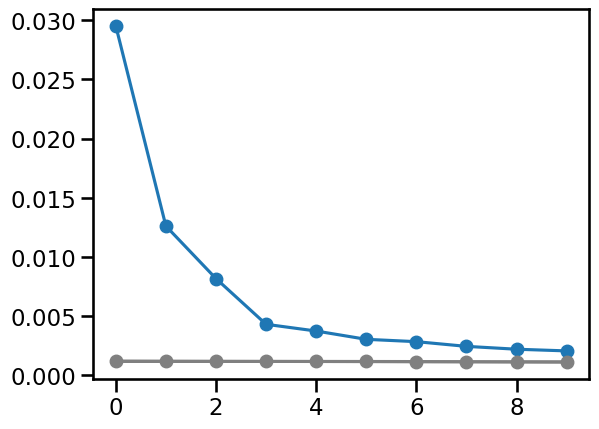

In [12]:
avg = np.mean(shuffled_evs, axis=0)
std = np.std(shuffled_evs, axis=0)

plt.plot(np.arange(10), pca.explained_variance_ratio_, '-o')
plt.plot(np.arange(10), avg, '-o', color='gray')
plt.fill_between(np.arange(10), 
                 avg-std, 
                 avg+std,
                 color='gray')

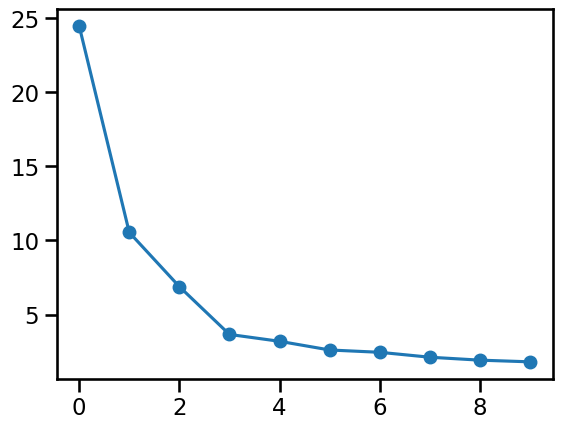

In [13]:
plt.plot(pca.explained_variance_ratio_/avg, '-o')

# screen for the number of archetypes

In [33]:
ndim = 10 
nrepeats = 10

np.random.seed(0)

skip_pc1 = True
noc_grid = np.arange(2, ndim+2) 
ev_grid = []
av_grid = []

sca.setup_feature_matrix(method='data')
for noc in noc_grid:
    xp, aa, ev = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1)
    
    aa_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)
    av = get_relative_variation(aa_boots)
    
    print(noc, ev, av)
    ev_grid.append(ev)
    av_grid.append(av)
    
ev_grid = np.array(ev_grid)
av_grid = np.array(av_grid)

use data
2 0.2889604687612088 0.02049372008327391
3 0.468052240190716 0.052895119027485296
4 0.5600061176936719 0.8359732632473265
5 0.6407538051364724 1.1639588208944855
6 0.6909997452990693 1.1643126393183778
7 0.7464623276144012 1.6138795794624285
8 0.7877271296607025 1.7243453165446154
9 0.8301047308149376 1.8932071765255196
10 0.8657775141695605 1.9987399983209329
11 0.8670764652763048 2.110248016490748


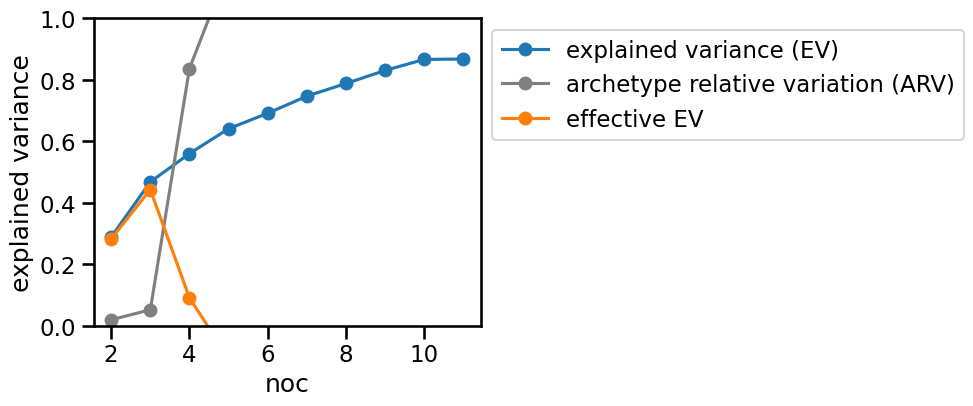

In [34]:
fig, ax = plt.subplots(1,1,figsize=(1*5,1*4))
pf = 10

ax.plot(noc_grid[:pf], ev_grid[:pf], '-o', label='explained variance (EV)')
ax.plot(noc_grid[:pf], av_grid[:pf], '-o', color='gray', label='archetype relative variation (ARV)')
ax.plot(noc_grid[:pf], ev_grid[:pf]*(1-av_grid[:pf]), '-o', label='effective EV')
ax.set_xlabel('noc')
ax.set_ylabel('explained variance')
ax.set_ylim([0,1])
ax.legend(bbox_to_anchor=(1,1))


# show one structure

In [36]:
noc  = 3 
ndim = noc-1
nrepeats = 3

In [37]:
# data 
skip_pc1 = True
sca.setup_feature_matrix(method='data')
xp, aa, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1) #skip_pc1)
aa_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)

use data


In [38]:
# gshuff
sca.setup_feature_matrix(method='gshuff')
xp_gshuff, aa_gshuff, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1)
aa_gshuff_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)

use shuffled data


In [39]:
# tshuff 
sca.setup_feature_matrix(method='tshuff')
xp_tshuff, aa_tshuff, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1)
aa_tshuff_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)

use per-type shuffled data


## plot

In [40]:
types_colorvec = np.char.add('C', sca.types_idx.astype(str))

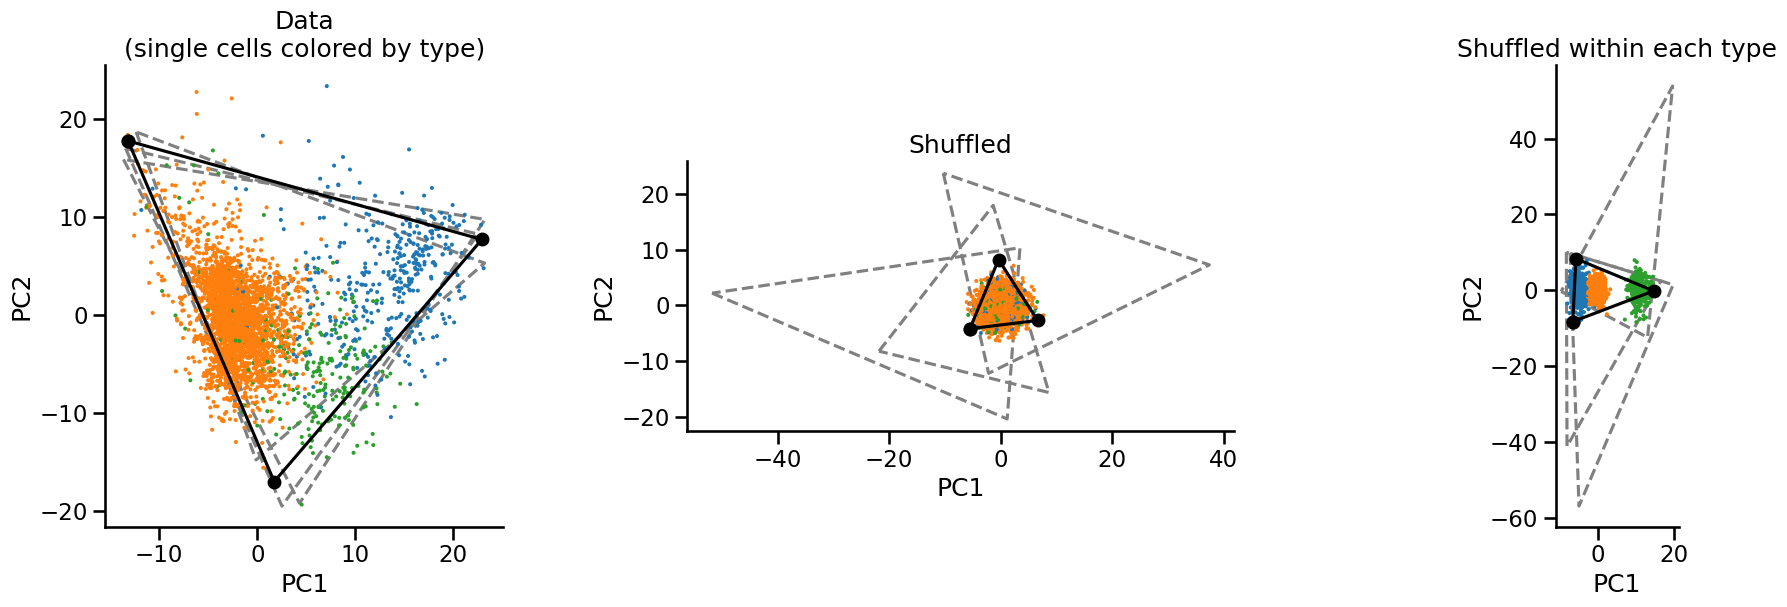

In [41]:
# plot
fig, axs = plt.subplots(1,3,figsize=(8*3,6))
ax = axs[0]
ax.scatter(xp[:,0], xp[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')
    
ax = axs[1]
ax.set_title('Shuffled')
ax.scatter(xp_gshuff[:,0], xp_gshuff[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa_gshuff, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_gshuff_boots[i], fmt='--', color='gray', zorder=0)

ax = axs[2]
ax.set_title('Shuffled within each type')
ax.scatter(xp_tshuff[:,0], xp_tshuff[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa_tshuff, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_tshuff_boots[i], fmt='--', color='gray', zorder=0)

for i in range(3):
    ax = axs[i]
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_aspect('equal')
    sns.despine(ax=ax)
    ax.grid(False)
    
plt.show()

In [42]:
adata_hvg.obs.cluster_label

AAACATGCATCTAGCA-L8XR_220331_02_A11-1170314855    5228_Astro-TE NN_4
AAACCGGCAAGCTTTG-L8XR_220331_02_A11-1170314855    5225_Astro-TE NN_3
AAACCGGCAGGCATCT-L8XR_220331_02_A11-1170314855    5225_Astro-TE NN_3
AAACCGGCATAATCGT-L8XR_220331_02_A11-1170314855    5225_Astro-TE NN_3
AAAGCCGCAGCTAACC-L8XR_220331_02_A11-1170314855    5225_Astro-TE NN_3
                                                         ...        
TTGTTGCGTCCCGGAA-L8XR_220721_02_D06-1196254077    5225_Astro-TE NN_3
TTGTTGTTCGATTTAG-L8XR_220721_02_D06-1196254077    5225_Astro-TE NN_3
TTTAGGATCAGGCTAT-L8XR_220721_02_D06-1196254077    5225_Astro-TE NN_3
TTTCATCAGCAGGCCT-L8XR_220721_02_D06-1196254077    5225_Astro-TE NN_3
TTTGCGACATTAAGCT-L8XR_220721_02_D06-1196254077    5225_Astro-TE NN_3
Name: cluster_label, Length: 3390, dtype: category
Categories (3, object): ['5218_Astro-TE NN_1', '5225_Astro-TE NN_3', '5228_Astro-TE NN_4']

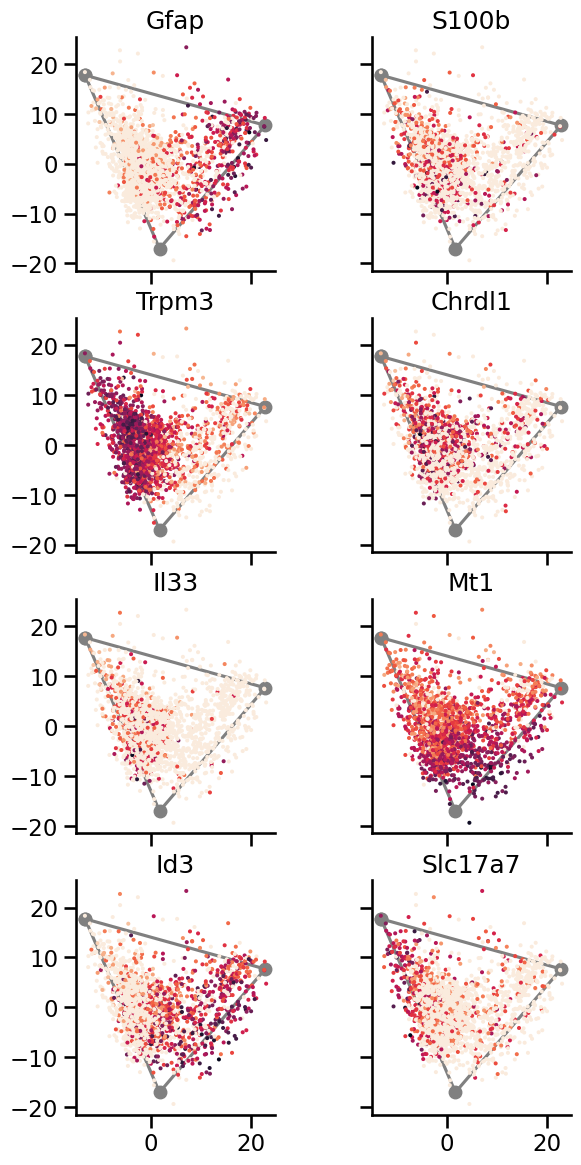

In [75]:
gns = [
    'Gfap', 'S100b', 
    'Trpm3', 'Chrdl1', 'Il33',
    'Mt1', 'Id3', 'Slc17a7',
    
]
n = len(gns)
nx = 2
ny = int((n+nx-1)/nx)

fig, axs = plt.subplots(ny,nx,figsize=(3.5*nx,3.5*ny), sharex=True, sharey=True)
for i, gn in enumerate(gns):
    ax = axs.flat[i]
    # gexp = np.array(adata_hvg[:,gn].layers['lognorm']).reshape(-1,)
    gexp = np.array(adata_ag[:,gn].X.todense()).reshape(-1,)
    g = ax.scatter(xp[:,0], xp[:,1], c=gexp, s=2, cmap='rocket_r')
    plot_archetype(ax, aa, fmt='-o', color='gray', zorder=0)
    # fig.colorbar(g, shrink=0.2, aspect=5)
    ax.set_aspect('equal')
    sns.despine(ax=ax)
    ax.set_title(gn)

# for i in range(nrepeats):
#     plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)

In [44]:
# data 
skip_pc1 = True
ndim = 3
noc = 4

sca.setup_feature_matrix(method='data')
xp2, aa2, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1) #skip_pc1)

use data


In [48]:
fig = px.scatter_3d(df, x='x', y='y', z='z',
                    color='cluster', 
                    # color_continuous_scale='viridis', 
                    # range_color=[vmin, vmax],
                   ) 

fig.update_traces(marker_size=3) 
fig.update_layout(width=1000, height=800)
fig.update_scenes(xaxis_autorange="reversed") 
fig.update_layout(scene_dragmode='orbit')
fig.show()

In [49]:
df_aa2 = pd.DataFrame(aa2.T)

array([[-11.57965796,  -3.47221042,   7.8671007 ,  22.83055287],
       [ 19.38256602, -11.47223909, -11.34663574,   6.57530405],
       [  4.16936347,  -9.1898678 ,  15.21419637,  -5.3664158 ]])

In [51]:
# 1. Define your points (Nodes)
x = aa2[0]
y = aa2[1]
z = aa2[2]

pairs = [(0, 1), 
         (0, 2),
         (0, 3),
         (1, 2),
         (1, 3),
         (2, 3),
        ]

x_lines, y_lines, z_lines = [], [], []

for start_idx, end_idx in pairs:
    # Add start point coordinates
    x_lines.extend([x[start_idx], x[end_idx], None])
    y_lines.extend([y[start_idx], y[end_idx], None])
    z_lines.extend([z[start_idx], z[end_idx], None])

In [71]:
gns = [
    'Gfap', 'S100b', 
    'Trpm3', 'Chrdl1', 'Il33',
    'Mt1', 'Id3', 
    'Atp2b2', 'Gabbr2',
    'Unc13c', 'Agt',
    'Ptn', 'Slc17a7'
    
]

In [72]:
# df = np.array(adata_hvg[:,gns].layers['lognorm']) # .reshape(-1,)
df = np.array(adata_ag[:,gns].X.todense()) # .reshape(-1,)
df = pd.DataFrame(df, columns=gns)
df['x'] = xp2[:,0]
df['y'] = xp2[:,1]
df['z'] = xp2[:,2]
df['cluster'] = adata_hvg.obs['cluster_label'].values
df

,Gfap,S100b,Trpm3,Chrdl1,Il33,Mt1,Id3,Atp2b2,Gabbr2,Unc13c,Agt,Ptn,Slc17a7,x,y,z,cluster
0,2.100280,0.000000,0.000000,0.000000,1.754226,3.467713,1.754226,1.220678,0.000000,0.000000,0.0,2.100280,0.000000,14.572689,-7.035436,6.395823,5228_Astro-TE NN_4
1,0.000000,0.000000,3.057955,0.940127,0.940127,2.174926,0.000000,0.940127,0.000000,1.416002,0.0,3.128701,0.000000,-2.439062,-1.054687,0.871113,5225_Astro-TE NN_3
2,0.000000,0.000000,3.480557,0.000000,0.000000,2.657024,0.000000,1.786777,1.786777,2.031682,0.0,3.372947,0.000000,-2.537645,-2.474178,1.065190,5225_Astro-TE NN_3
3,0.000000,0.000000,2.350077,0.000000,1.859541,1.859541,0.000000,1.622471,1.311138,0.856624,0.0,3.286488,0.856624,-1.969463,-3.381475,2.358505,5225_Astro-TE NN_3
4,0.904807,0.000000,4.615703,0.000000,0.904807,1.689055,0.000000,1.929464,1.689055,0.000000,0.0,2.754586,0.000000,-2.396022,-0.301913,-0.699886,5225_Astro-TE NN_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,0.000000,0.000000,2.531637,2.072473,0.000000,1.728044,0.000000,1.198402,2.072473,3.083438,0.0,2.531637,0.000000,-5.268894,2.796326,0.303777,5225_Astro-TE NN_3
3386,0.000000,0.815120,4.558691,0.000000,0.000000,1.798037,0.000000,1.987495,2.146712,2.146712,0.0,2.404742,0.000000,-3.675579,4.833977,0.887301,5225_Astro-TE NN_3
3387,0.841549,0.841549,3.261138,1.291960,0.841549,2.028121,0.000000,0.841549,0.000000,0.841549,0.0,2.555646,0.000000,-2.967856,4.212244,3.039197,5225_Astro-TE NN_3
3388,0.000000,0.836425,2.675324,1.156934,0.000000,1.501467,1.009466,1.594183,0.627044,0.000000,0.0,2.547327,1.285425,-2.915838,8.978788,3.191722,5225_Astro-TE NN_3


In [73]:
import plotly.graph_objects as go


# 2. Create the initial figure
fig = go.Figure(data=[go.Scatter3d(
    x=df['x'], y=df['y'], z=df['z'],
    mode='markers',
    marker=dict(
        size=5,
        color=df['Gfap'],      # Initial color
        colorscale='Viridis',
        colorbar=dict(title="Value")
    )
)])

# Add archetypes
fig.add_trace(go.Scatter3d(x=x, y=y, z=z,
    mode='markers+lines',
    marker=dict(size=8, color='black', opacity=0.9, symbol='diamond')
))
fig.add_trace(go.Scatter3d(
    x=x_lines, y=y_lines, z=z_lines,
    mode='lines',
    line=dict(color='gray', width=2),
    hoverinfo='none'
))

# 3. Add the Dropdown Menu
fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label=gn,
                    method="restyle",
                    args=[{"marker.color": [df[gn]], 
                           "marker.cmin": np.percentile(df[gn],  5),
                           "marker.cmax": np.percentile(df[gn], 95),
                          }] # Note: data must be in a list
                ) for gn in gns
            ],
            direction="down",
            showactive=True,
            x=0.1, y=1.15
        )
    ]
)

fig.update_layout(width=1000, height=800)

fig.update_scenes(xaxis_autorange="reversed") 
fig.update_layout(scene_dragmode='orbit')
fig.show()


In [74]:
import plotly.graph_objects as go


# 2. Create the initial figure
fig = go.Figure(data=[go.Scatter3d(
    x=df['x'], y=df['y'], z=df['z'],
    mode='markers',
    marker=dict(
        size=3,
        color='gray',
    )
)])

# Add archetypes
fig.add_trace(go.Scatter3d(x=x, y=y, z=z,
    mode='markers+lines',
    marker=dict(size=8, color='black', opacity=0.9, symbol='diamond')
))
fig.add_trace(go.Scatter3d(
    x=x_lines, y=y_lines, z=z_lines,
    mode='lines',
    line=dict(color='black', width=4),
    hoverinfo='none'
))

# 3. Add the Dropdown Menu
fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label=gn,
                    method="restyle",
                    args=[{"marker.color": [df[gn]], 
                           "marker.cmin": np.percentile(df[gn],  5),
                           "marker.cmax": np.percentile(df[gn], 95),
                          }] # Note: data must be in a list
                ) for gn in gns
            ],
            direction="down",
            showactive=True,
            x=0.1, y=1.15
        )
    ]
)

fig.update_layout(width=1000, height=800)

fig.update_scenes(xaxis_autorange="reversed") 
fig.update_layout(scene_dragmode='orbit')
fig.show()
